# CBOE SKEW — a quantitative teardown 🔬
### Forward returns on SKEW *controlling for VIX* (HAC) · the bucket *t* vs its block-bootstrap correction · a tail-warning test vs base rate · a costed fade sleeve · a planted-edge control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Warns_before_crashes%3F: Busted](https://img.shields.io/badge/Warns_before_crashes%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The believers' claim about SKEW is **incremental**: it warns when VIX is calm. So the decisive object is **SKEW's coefficient in a forward-return regression that already controls for VIX**, read with **HAC (Newey-West)** standard errors — overlapping forward-return windows are heavily autocorrelated, so a naive *t* is a pseudo-replication trap.

> ⚠️ **Data note.** Real data: yfinance daily closes for `^SKEW`, `^VIX`, `SPY`, joint window 1993-01-29→2026-06-18 (8,330 days). SPY is **price-only** (no dividends; labelled on the Tradability axis). Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from skew_index import data, strategy as st

HAVE_REAL = data.have_real()
F = data.load_real() if HAVE_REAL else None
print("real SKEW/VIX/SPY cache present:", HAVE_REAL,
      "| joint days:", (0 if F is None else len(F)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '1993-01-29', 'end': '2026-06-18', 'days': 8330, 'years': 33.4, 'skew_mean': 123.7, 'vix_mean': 19.5, 'corr': -0.19, 'reg1': (1, 8308, 0.057, 0.35, 0.427, 1.54), 'reg3': (3, 8266, 0.247, 0.49, 0.89, 1.13), 'dec1': (1, 831, 1.02, 0.97, 69, 65, 0.37, 0.619), 'dec3': (3, 827, 2.37, 2.94, 71, 72, -2.33, 0.026), 'blk1': (1, 0.05, 0.38, 0.13, 23), 'blk3': (3, -0.57, 1.13, -0.5, 13), 'tail10': (-10, 1.7, 4.4, 1.0), 'tail5': (-5, 13.7, 17.3, 0.998), 'sleeve_cagr': 9.04, 'sleeve_sharpe': 0.57, 'bh_cagr': 10.94, 'bh_sharpe': 0.65, 'pct_cash': 10, 'syn': [(0.0, 7978, 0.109, 0.42), (0.0005, 7978, -0.764, -2.85)]}


real SKEW/VIX/SPY cache present: True | joint days: 8330


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | VIX-controlled HAC **t(SKEW) = +0.35** (1m) / **+0.49** (3m) — far below 2, *positive*-signed. The 3m bucket Welch **t = -2.33** is pseudo-replication: ~13 episodes, block-bootstrap **t = -0.50**. |
| **Tradability** | `MIRAGE` | Fade-high-SKEW sleeve **9.0%** CAGR / Sharpe **0.57** vs buy-hold **10.9%** / **0.65** — strictly worse. |
| **Warns before crashes?** | `BUSTED` | −10% forward drawdown rate **1.7%** after high SKEW vs **4.4%** base (placebo p ≈ 1.00). The tail gauge precedes *fewer* tails. |

> 💡 In plain words: SKEW and VIX are both risk-neutral moments of the same option surface; once VIX is in the regression SKEW adds nothing, and the implied tail it prices is the tail the market *fears*, which is empirically the tail that mostly doesn't arrive.

## 1 · The claim, steelmanned

Let $S_t$ = SKEW, $V_t$ = VIX, and $r_{t\to t+H}$ the forward $H$-month SPY return entered one day after $t$. The hypotheses:

- **H₁ (incremental signal).** In $r_{t\to t+H} = \alpha + \beta_S \tilde S_t + \beta_V \tilde V_t + \varepsilon$ (predictors standardised), $\beta_S < 0$ with a robust $|t| \ge 2$ — SKEW predicts weaker forward returns **beyond VIX**.
- **H₂ (tail warning).** $\Pr[\text{drawdown} < d \mid S_t \text{ high}] > \Pr[\text{drawdown} < d]$ — a high SKEW raises the forward tail-event probability.
- **H₃ (deployable).** A rule that de-risks on high SKEW beats buy-and-hold net of costs.

We find **H₁ rejected** ($t_S \approx +0.4$, wrong sign), **H₂ rejected** (the tail rate *falls*), **H₃ rejected** (the sleeve loses). The lone artifact — a 3m bucket Welch $t=-2.33$ — dies under a block bootstrap that respects the ~13 distinct episodes.

## 2 · So what? — what rides on each answer

The crux is **collinearity vs orthogonality**. SKEW and VIX are both extracted from the OTM S&P 500 option surface, so the only economically interesting part of SKEW is its component **orthogonal to VIX**. The right instrument is therefore the multivariate slope:

$$\hat\beta_S = \frac{\mathrm{Cov}(r,\ \tilde S \mid \tilde V)}{\mathrm{Var}(\tilde S \mid \tilde V)},\qquad t_S = \hat\beta_S / \mathrm{se}_{\mathrm{HAC}}(\hat\beta_S).$$

Overlapping daily forward windows make $\varepsilon$ strongly autocorrelated, so OLS standard errors are badly understated; **Newey-West** (lags = horizon) is mandatory. A **bucket** comparison (top-decile SKEW vs rest) is even more dangerous: its naive Welch *t* treats 800+ overlapping days as independent, while the *effective* sample is the number of **distinct high-SKEW episodes** — which a **block bootstrap** exposes.

## 3 · How we'd know — the protocol

- **Tape.** Daily `^SKEW`, `^VIX`, `SPY` closes, joint window 1993-01-29→2026-06-18 (8,330 days, 33y). SKEW mean **123.7**, VIX mean **19.5**, corr **-0.19**.
- **Forward returns.** Enter the close **1 day after** the signal (no look-ahead); horizons $H \in \{1, 3\}$ months.
- **Decisive test (Signal).** OLS of forward return on standardised SKEW *and* VIX; **HAC (Newey-West)** *t* with lags = horizon. Read $t_S$.
- **Bucket + correction.** Top-decile SKEW vs rest (naive Welch *t* + placebo), then a **circular block bootstrap** (block = horizon) and an **episode count** for the honest *t*.
- **Tail warning (myth axis).** Forward 1-month worst-drawdown ≤ {−5%, −10%}; conditional tail rate vs base rate, placebo *p*.
- **Tradability.** A long/flat sleeve to cash while SKEW is top-decile (1-day lag, 2-bps one-way × turnover) vs buy-and-hold SPY, on the same tape.
- **Positive control.** A deterministic (SKEW, VIX, SPY) panel with a **planted-edge knob** in the VIX-orthogonal part of SKEW: $t_S$ must stay quiet at edge 0 and light up when on.

## 4 · The teardown

### 4a · The decisive regression — SKEW controlling for VIX

Forward-return slope on standardised SKEW *and* VIX, with HAC (Newey-West) *t*-stats. $t_S$ is SKEW's *incremental* coefficient.

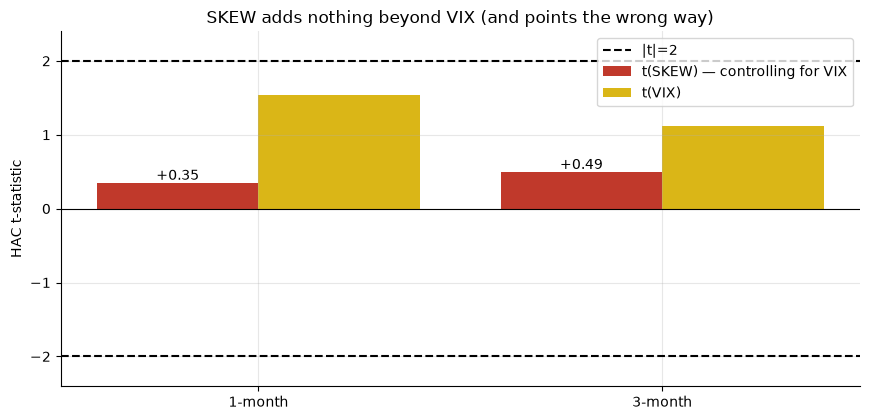

t(SKEW | VIX): {'1m': 0.35, '3m': 0.49}


In [2]:
hs = [1, 3]
if HAVE_REAL:
    ts_skew = [st.regress_forward(F,m)['t_skew'] for m in hs]
    ts_vix  = [st.regress_forward(F,m)['t_vix']  for m in hs]
else:
    ts_skew = [R['reg1'][3], R['reg3'][3]]; ts_vix = [R['reg1'][5], R['reg3'][5]]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.bar(x-.2, ts_skew, .4, color=RED, label='t(SKEW) — controlling for VIX')
ax.bar(x+.2, ts_vix, .4, color=AMBER, label='t(VIX)')
ax.axhline(2, ls='--', c='k', label='|t|=2'); ax.axhline(-2, ls='--', c='k')
ax.axhline(0, c='k', lw=.8)
ax.set_xticks(x); ax.set_xticklabels([f'{m}-month' for m in hs]); ax.set_ylabel('HAC t-statistic')
ax.set_ylim(-2.4, 2.4); ax.set_title('SKEW adds nothing beyond VIX (and points the wrong way)')
for i,t in enumerate(ts_skew): ax.annotate(f'{t:+.2f}',(i-.2,t),ha='center',va='bottom')
ax.legend(); plt.tight_layout(); plt.show()
print('t(SKEW | VIX):', {f'{m}m': round(t,2) for m,t in zip(hs,ts_skew)})

> 💡 In plain words: SKEW's own *t* is **+0.35** (1m) / **+0.49** (3m) — not just insignificant but the *wrong sign* for a crash warning (higher SKEW → marginally *higher* forward returns). Even VIX barely registers at these horizons. **H₁ rejected:** there is no information in SKEW orthogonal to VIX.

### 4b · The bucket *t* and why it's a mirage

The top-decile-SKEW bucket shows a 3-month Welch *t* near −2.3 — tempting. But those days cluster into ~a dozen episodes. The block bootstrap (block = horizon), respecting the autocorrelation, gives the honest *t*.

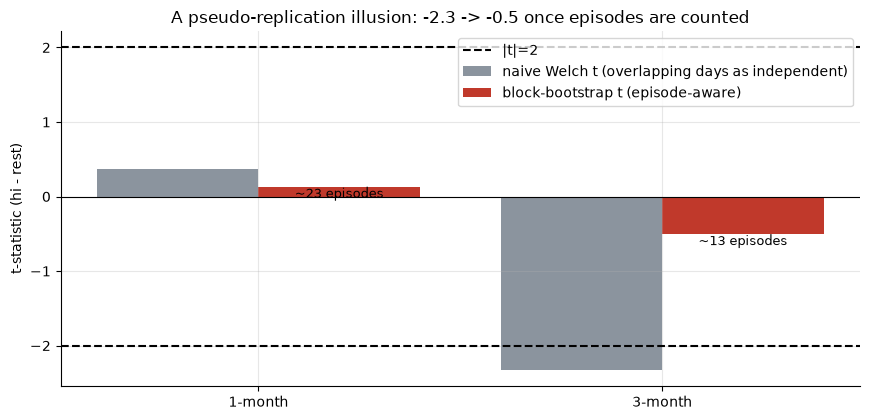

3m: naive t = -2.33 -> block-bootstrap t = -0.5 on ~13 episodes


In [3]:
if HAVE_REAL:
    naive = [st.decile_summary(F,m)['t'] for m in hs]
    bb = [st.block_bootstrap_decile(F,m) for m in hs]
    honest = [b['block_t'] for b in bb]; eps = [b['n_episodes'] for b in bb]
else:
    naive = [R['dec1'][6], R['dec3'][6]]; honest = [R['blk1'][3], R['blk3'][3]]; eps = [R['blk1'][4], R['blk3'][4]]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.bar(x-.2, naive, .4, color=GREY, label='naive Welch t (overlapping days as independent)')
ax.bar(x+.2, honest, .4, color=RED, label='block-bootstrap t (episode-aware)')
ax.axhline(-2, ls='--', c='k', label='|t|=2'); ax.axhline(2, ls='--', c='k'); ax.axhline(0, c='k', lw=.8)
ax.set_xticks(x); ax.set_xticklabels([f'{m}-month' for m in hs]); ax.set_ylabel('t-statistic (hi - rest)')
ax.set_title('A pseudo-replication illusion: -2.3 -> -0.5 once episodes are counted')
for i,(h,e) in enumerate(zip(honest,eps)): ax.annotate(f'~{e} episodes',(i+.2,h),ha='center',va='top',fontsize=9)
ax.legend(); plt.tight_layout(); plt.show()
print('3m: naive t =', round(naive[1],2), '-> block-bootstrap t =', round(honest[1],2), f'on ~{eps[1]} episodes')

> 💡 In plain words: the naive 3m *t* of **-2.33** assumes **827** independent observations; there are really ~**13** distinct high-SKEW episodes, and the episode-aware *t* is **-0.50**. The "significant" bucket was an artifact of counting overlapping windows as independent — the single most common way a volatility-folklore signal fakes significance.

### 4c · The tail-warning claim — the myth axis

SKEW's entire reputation is *tail* insurance. So directly: after a high SKEW, is a forward drawdown more likely than usual? Conditional tail rate vs base rate, with a placebo null.

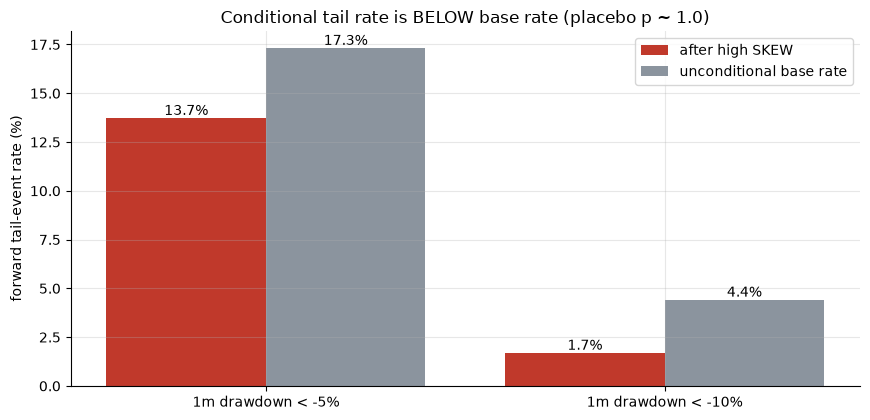

placebo p (P[random draw >= conditional rate]): {'-5%': 1.0, '-10%': 1.0}


In [4]:
if HAVE_REAL:
    t5 = st.tail_warning(F,1,dd=-0.05); t10 = st.tail_warning(F,1,dd=-0.10)
    hi = [t5['hi_tail_rate']*100, t10['hi_tail_rate']*100]
    base = [t5['base_tail_rate']*100, t10['base_tail_rate']*100]
    ps = [t5['p_placebo'], t10['p_placebo']]
else:
    hi = [R['tail5'][1], R['tail10'][1]]; base = [R['tail5'][2], R['tail10'][2]]; ps = [R['tail5'][3], R['tail10'][3]]
x = np.arange(2)
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.bar(x-.2, hi, .4, color=RED, label='after high SKEW')
ax.bar(x+.2, base, .4, color=GREY, label='unconditional base rate')
ax.set_xticks(x); ax.set_xticklabels(['1m drawdown < -5%','1m drawdown < -10%'])
ax.set_ylabel('forward tail-event rate (%)')
ax.set_title('Conditional tail rate is BELOW base rate (placebo p ~ 1.0)')
for i,(h,b) in enumerate(zip(hi,base)):
    ax.annotate(f'{h:.1f}%',(i-.2,h),ha='center',va='bottom')
    ax.annotate(f'{b:.1f}%',(i+.2,b),ha='center',va='bottom')
ax.legend(); plt.tight_layout(); plt.show()
print('placebo p (P[random draw >= conditional rate]):', {'-5%':round(ps[0],2), '-10%':round(ps[1],2)})

> 💡 In plain words: the conditional −10% rate is **1.7%** vs a base **4.4%**; the placebo *p* ≈ **1.00** says a random draw essentially *always* shows more tail risk than the high-SKEW set. **H₂ rejected, with the sign inverted:** high SKEW marks priced-but-unrealised fear. The gauge fires before calm.

### 4d · Faithful-engine & planted-edge control — we know the truth here

A deterministic (SKEW, VIX, SPY) panel with corr(SKEW, VIX) ≈ 0.70 and a knob that plants a **VIX-orthogonal** predictive edge in SKEW. With the knob **off** the VIX-controlled HAC *t* must stay below 2 (no false positive); with a real edge it must light up — proving the engine is unbiased and the real-tape null is genuine.

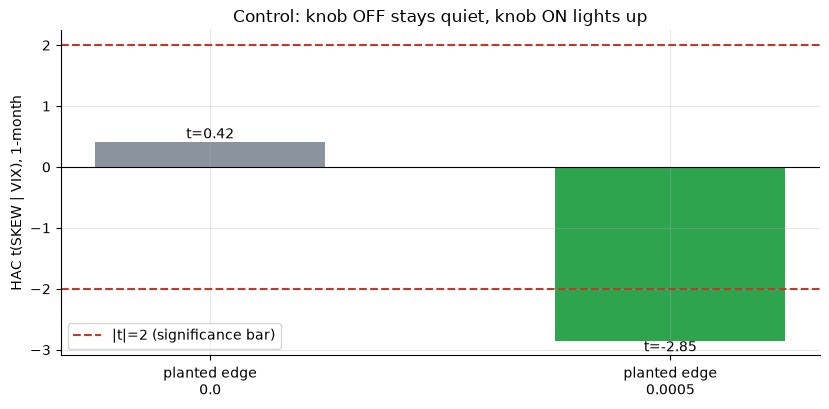

planted edge=0.0: t(SKEW|VIX)=+0.42
planted edge=0.0005: t(SKEW|VIX)=-2.85


In [5]:
res = []
for edge in (0.0, 0.0005):
    syn = data.synthetic_panel(edge=edge, seed=371)
    r = st.regress_forward(syn, 1); res.append((edge, r['t_skew']))
labels = [f'planted edge\n{e}' for e,_ in res]; tvals = [t for _,t in res]
fig, ax = plt.subplots(figsize=(8.4, 4.2))
ax.bar(labels, tvals, color=[GREY, GREEN], width=.5)
ax.axhline(-2, ls='--', c=RED, label='|t|=2 (significance bar)'); ax.axhline(2, ls='--', c=RED); ax.axhline(0, c='k', lw=.8)
for i,t in enumerate(tvals): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom' if t>=0 else 'top')
ax.set_ylabel('HAC t(SKEW | VIX), 1-month'); ax.set_title('Control: knob OFF stays quiet, knob ON lights up'); ax.legend()
plt.tight_layout(); plt.show()
for e,t in res: print(f'planted edge={e}: t(SKEW|VIX)={t:+.2f}')

> 💡 In plain words: with **no** planted edge the control sits at **t = +0.42** (no false positive); a genuine VIX-orthogonal edge drives **t = -2.85** with the correct negative sign. The machinery detects a real SKEW signal when one exists — so the real-tape **t = +0.35** is what an *absent* incremental signal looks like, not a power failure.

## 5 · The verdict

- **Signal `NONE`** — VIX-controlled HAC **t(SKEW) = +0.35** (1m) / **+0.49** (3m), below 2 and wrong-signed. The 3m bucket Welch **t = -2.33** is pseudo-replication (≈13 episodes → block-bootstrap **t = -0.50**). No information beyond VIX ⇒ NONE, not WEAK.
- **Tradability `MIRAGE`** — fade-high-SKEW sleeve **9.0%** CAGR / Sharpe **0.57** vs buy-hold **10.9%** / **0.65**. De-risking on the "warning" strictly *lowers* return and risk-adjusted return.
- **Warns before crashes? `BUSTED`** — −10% forward drawdown rate **1.7%** after high SKEW vs **4.4%** base (placebo p ≈ 1.00). The black-swan gauge prices fear that mostly doesn't realise; it fires before calm.

## 6 · Could you trade it? — the cost of crying wolf

The operational truth: the fade sleeve sits in cash ~10% of days and *gives up* the return of those days for nothing. Here is the equity curve of the "warning" trade against simply holding SPY.

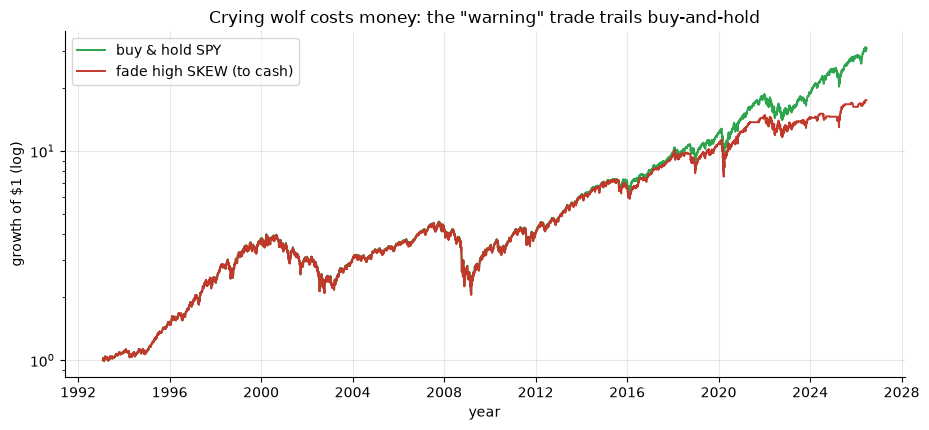

final wealth — buy-hold: 31.0x   fade sleeve: 17.5x


In [6]:
if HAVE_REAL:
    ret = F['spy'].pct_change().fillna(0.0)
    thr = F['skew'].quantile(0.90)
    in_mkt = (F['skew'] < thr).shift(1).fillna(True).astype(float)
    pos_change = in_mkt.diff().abs().fillna(0.0)
    sleeve = (in_mkt*ret - pos_change*(2/1e4))
    eq_sleeve = (1+sleeve).cumprod(); eq_bh = (1+ret).cumprod()
    fig, ax = plt.subplots(figsize=(9.4, 4.4))
    ax.plot(eq_bh.index, eq_bh.values, c=GREEN, lw=1.4, label='buy & hold SPY')
    ax.plot(eq_sleeve.index, eq_sleeve.values, c=RED, lw=1.4, label='fade high SKEW (to cash)')
    ax.set_yscale('log'); ax.set_ylabel('growth of $1 (log)'); ax.set_xlabel('year')
    ax.set_title('Crying wolf costs money: the "warning" trade trails buy-and-hold'); ax.legend()
    plt.tight_layout(); plt.show()
    print(f'final wealth — buy-hold: {eq_bh.iloc[-1]:.1f}x   fade sleeve: {eq_sleeve.iloc[-1]:.1f}x')
else:
    print('no cache — frozen: sleeve', R['sleeve_cagr'], '% vs buy-hold', R['bh_cagr'], '%')

> 💡 In plain words: the red line trails the green one throughout — there is no episode where sitting out high-SKEW days rescued the portfolio, because high-SKEW days simply aren't where the losses concentrate. The entire economic content of "de-risk when SKEW is high" is **a small, persistent drag from missing good days**. There is no threshold, horizon, or cost regime that turns priced-but-unrealised tail fear into an edge.

## 7 · Going further

- **Implied vs realised tails.** SKEW is a clean *risk-neutral* third moment — a measure of what the option market **charges** for the tail, i.e. tail *fear*. Realised tail risk is a different object; the variance-risk-premium literature (Bakshi-Kapadia-Madan; Bollerslev-Tauchen-Zhou) is the right lens for *why* priced fear and realised outcomes diverge.
- **Orthogonalised SKEW.** Regress SKEW on VIX first and test only the residual — it is exactly the multivariate slope here, and it is null. There is no hidden signal in the VIX-orthogonal component.
- **Cross-section vs index.** Option-implied skewness *does* show up in the cross-section of single stocks (Conrad-Dittmar-Ghysels); that is not the CBOE index-timing claim tested here, and conflating the two is the usual source of the SKEW myth.

*The reproducible core is offline and deterministic. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*